# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

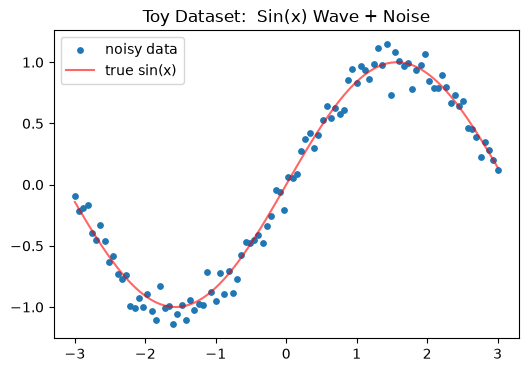

Final parameters: w=0.3390, b=-0.0102, final boss0.19545182324473478=0.1955


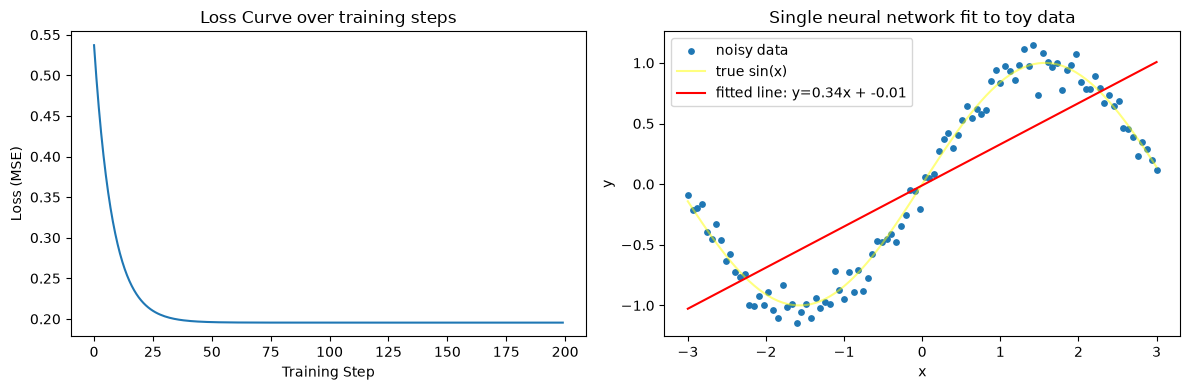

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, label="noisy data")
plt.plot(x, np.sin(x), color='red', label="true sin(x)", alpha = 0.6)
plt.legend()
plt.title("Toy Dataset:  Sin(x) Wave + Noise")
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w=np.random.randn() * 0.01
b=np.random.randn() * 0.01


# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.01
n_steps = 200
losses = []

#forward pass
for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)
#Gradient calculation derived from d(loss)/dw and d(loss)/db    
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
#Parameter update    
    w -= lr * dw
    b -= lr * db
print(f"Final parameters: w={w:.4f}, b={b:.4f}, final boss{loss}={losses[-1]:.4f}")    

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses)
axes[0].set_title("Loss Curve over training steps")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss (MSE)")

axes[1].scatter(x, y, s=15, label="noisy data")
axes[1].plot(x, np.sin(x), color='yellow', label="true sin(x)", alpha = 0.5)
axes[1].plot(x, w * x + b, color='red', label=f"fitted line: y={w:.2f}x + {b:.2f}") 
axes[1].set_title("Single neural network fit to toy data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 
It is underfitting. This is because the loss plateau model has already found the best possible line for this data, and not because training failed, but because it succeeded and hit a ceiling.

A single neuron can never fit a sine wave because it only computes y_hat=wx+b, which is a straight line. And a straight line cannot represent a curve that changes direction the way a sine wave does, no matter how long it trains. 




![derivation](derivation_dw.jpeg)


![derivation](derivation_dw1.jpeg)

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

final loss: 0.01503


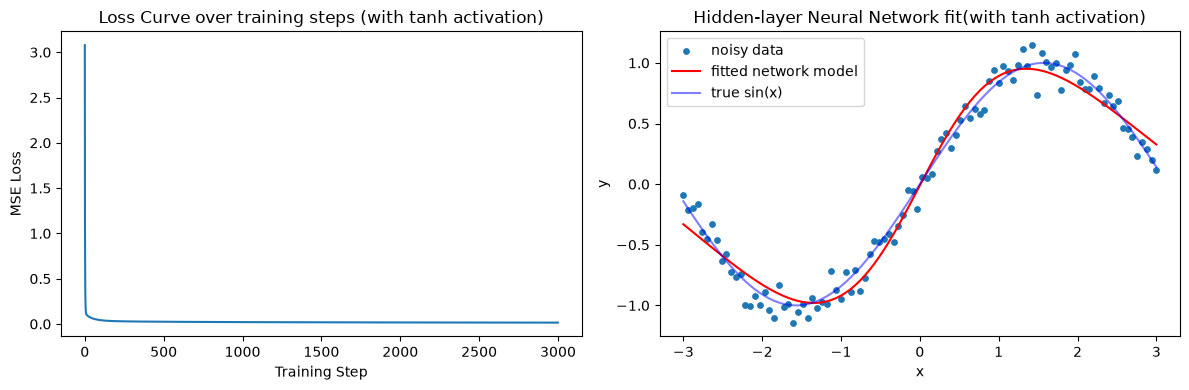

final loss without tanh: 0.19545


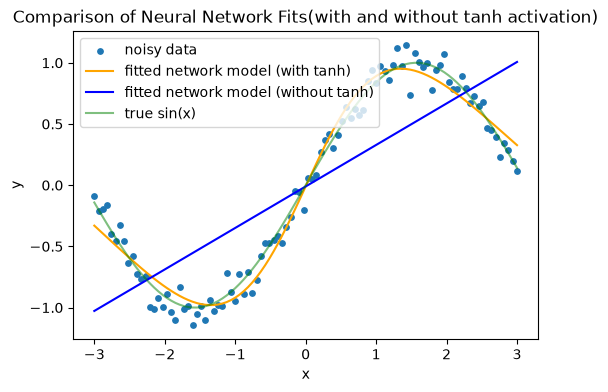

In [5]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)
x_input = x.reshape(-1, 1)  # Reshape x to be a column vector for matrix multiplication
y_target = y.reshape(-1, 1)  # Reshape y to be a column vector for consistency

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
learning_rate = 0.05
n_steps = 3000
loss_history = []

for step in range(n_steps):
    hidden_preactivation = x_input @ W1 + b1
    hidden_output = np.tanh(hidden_preactivation)
    y_hat = hidden_output @ W2 + b2
    loss = np.mean((y_hat - y_target) ** 2)
    loss_history.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    gradient_yhat = 2 * (y_hat - y_target) / len(y_target)
    gradient_W2 = hidden_output.T @ gradient_yhat
    gradient_b2 = gradient_yhat.sum(axis=0)
    gradient_hidden_output = gradient_yhat @ W2.T
    gradient_hidden_preactivation = gradient_hidden_output * (1 - np.tanh(hidden_preactivation) ** 2)
    gradient_W1 = x_input.T @ gradient_hidden_preactivation
    gradient_b1 = gradient_hidden_preactivation.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= learning_rate * gradient_W1
    b1 -= learning_rate * gradient_b1
    W2 -= learning_rate * gradient_W2
    b2 -= learning_rate * gradient_b2

print(f"final loss: {loss_history[-1]:.5f}")

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
fig,axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set_title("Loss Curve over training steps (with tanh activation)")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(x, y, s=15, label="noisy data")
axes[1].plot(x, y_hat.flatten(), color='red', label="fitted network model")
axes[1].plot(x, np.sin(x), color='blue', label="true sin(x)", alpha = 0.5)
axes[1].legend()
axes[1].set_title("Hidden-layer Neural Network fit(with tanh activation)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.tight_layout()
plt.show()

# Now re-run the training loop with the tanh activation removed
np.random.seed(RANDOM_STATE)
W1_no_tanh = np.random.randn(1, 8) * 0.5
b1_no_tanh = np.zeros(8)
W2_no_tanh = np.random.randn(8, 1) * 0.5
b2_no_tanh = np.zeros(1)
loss_history_no_tanh = []

for step in range(n_steps):
    #forward pass without tanh
    hidden_preactivation_no_tanh = x_input @ W1_no_tanh + b1_no_tanh
    hidden_output_no_tanh = hidden_preactivation_no_tanh  # No tanh activation
    y_hat_no_tanh = hidden_output_no_tanh @ W2_no_tanh + b2_no_tanh
    loss_no_tanh = np.mean((y_hat_no_tanh - y_target) ** 2)
    loss_history_no_tanh.append(loss_no_tanh)

    #backward pass without tanh
    gradient_yhat_no_tanh = 2 * (y_hat_no_tanh - y_target) / len(y_target)
    gradient_W2_no_tanh = hidden_output_no_tanh.T @ gradient_yhat_no_tanh
    gradient_b2_no_tanh = gradient_yhat_no_tanh.sum(axis=0)
    gradient_hidden_output_no_tanh = gradient_yhat_no_tanh @ W2_no_tanh.T
    gradient_hidden_preactivation_no_tanh = gradient_hidden_output_no_tanh * 1  # No tanh derivative
    gradient_W1_no_tanh = x_input.T @ gradient_hidden_preactivation_no_tanh
    gradient_b1_no_tanh = gradient_hidden_preactivation_no_tanh.sum(axis=0)

    #parameter update without tanh
    W1_no_tanh -= learning_rate * gradient_W1_no_tanh
    b1_no_tanh -= learning_rate * gradient_b1_no_tanh
    W2_no_tanh -= learning_rate * gradient_W2_no_tanh
    b2_no_tanh -= learning_rate * gradient_b2_no_tanh

print(f"final loss without tanh: {loss_history_no_tanh[-1]:.5f}")

#Plot comparison of loss curves and fits
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, label="noisy data")
plt.plot(x, y_hat.flatten(), color='orange', label="fitted network model (with tanh)")
plt.plot(x, y_hat_no_tanh.flatten(), color='blue', label="fitted network model (without tanh)")
plt.plot(x, np.sin(x), color='green', label="true sin(x)", alpha=0.5)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Neural Network Fits(with and without tanh activation)")
plt.show()


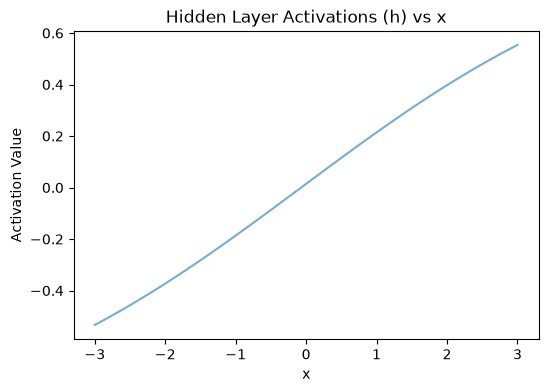

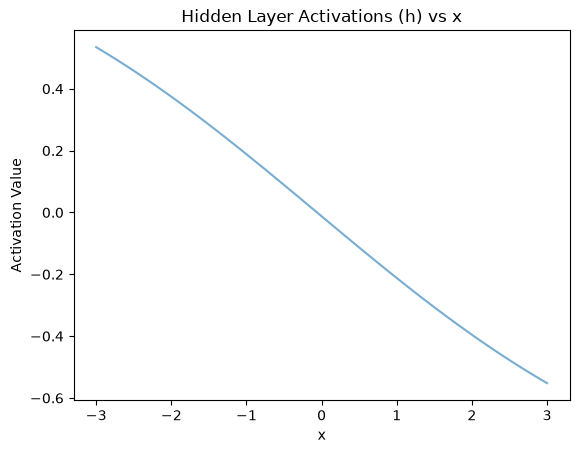

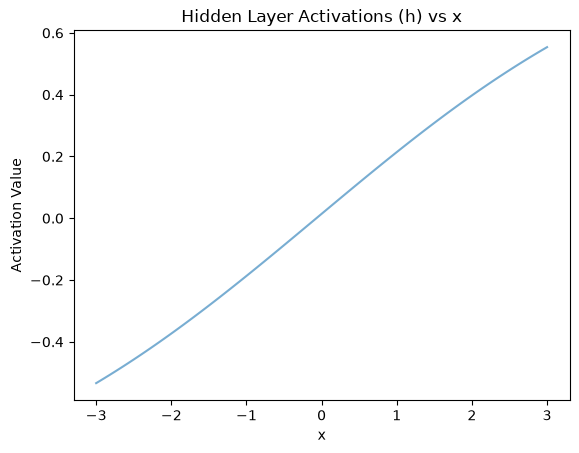

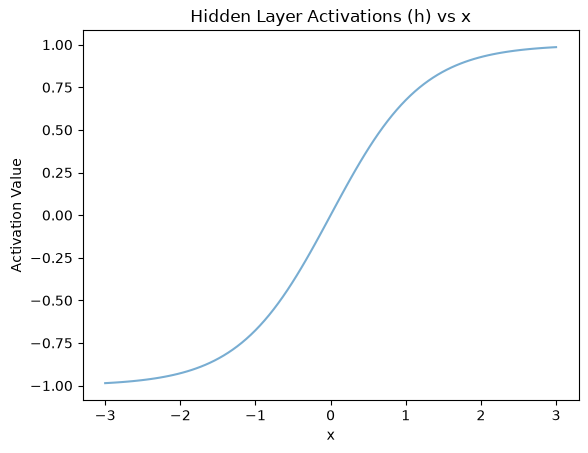

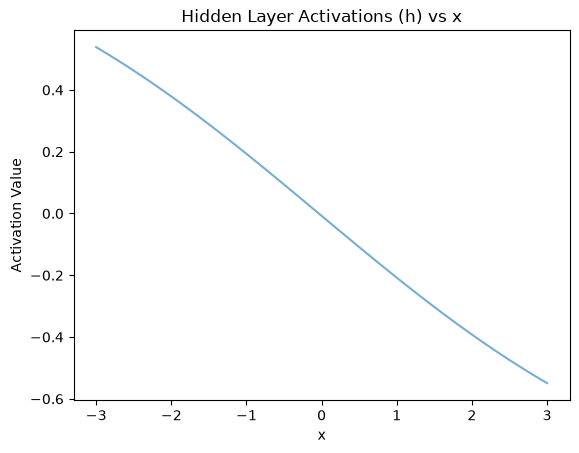

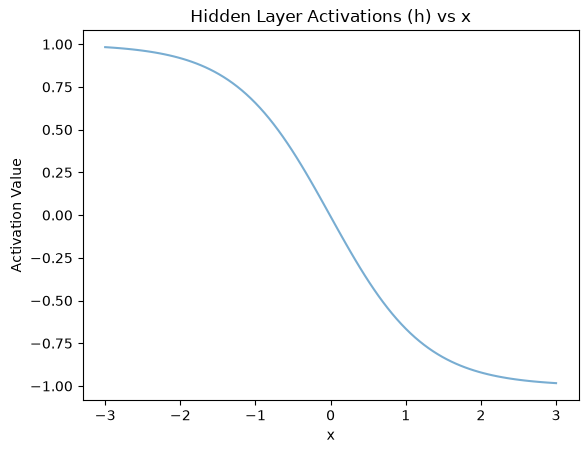

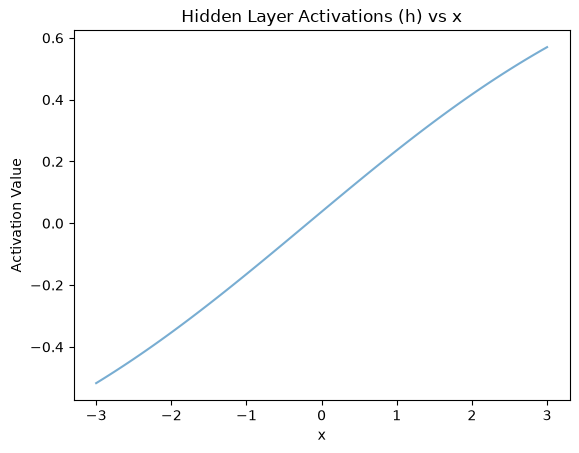

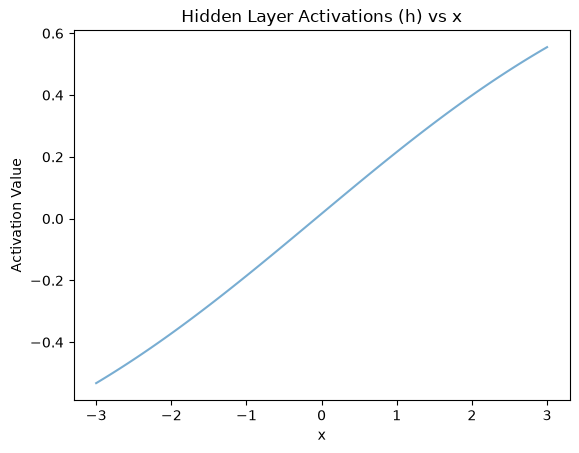

In [7]:
#Plotting few columns of h against x
plt.figure(figsize=(6, 4))
for i in range(hidden_output.shape[1]):
    plt.plot(x, hidden_output[:, i], label=f"h_{i+1}", alpha=0.6)
    plt.title("Hidden Layer Activations (h) vs x")
    plt.xlabel("x")
    plt.ylabel("Activation Value")
    plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 
1. y_hat​=(xW1​+b1​)W2​+b2​=x(W1​W2​)+(b1​W2​+b2​). From the equation since W1W2 and b1W2 +b2 are both fixed matrix and vectors, this collapses to y_hat = xW' +b', which is exactly the same form as a single neuron. So therefore stacking linear layers without a non-linearity never increases expressive power, no matter how many layers you add.
2. The 8 hidden neurons each learn their own bent tanh curve, bending at different points along x. The output layer combines these curves into one weighted sum. That combination of bends is what lets the network trace a curve like sine — something no single neuron could do alone.
3. Backpropagation applies the chain rule layer by layer, working backward from the output to the input, to compute how much each parameter in the network contributed to the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

lr=0.001: final loss for learning rate = 0.05549
lr=0.05: final loss for learning rate = 0.01503


C:\Users\hanso\AppData\Local\Temp\ipykernel_20832\688863376.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_target) ** 2)
C:\Users\hanso\AppData\Local\Temp\ipykernel_20832\688863376.py:23: RuntimeWarning: overflow encountered in matmul
  gradient_hidden_output = gradient_yhat @ W2.T
C:\Users\hanso\AppData\Local\Temp\ipykernel_20832\688863376.py:24: RuntimeWarning: invalid value encountered in multiply
  gradient_hidden_preactivation = gradient_hidden_output * (1 - np.tanh(hidden_preactivation) ** 2)


lr=1.0: final loss for learning rate = nan


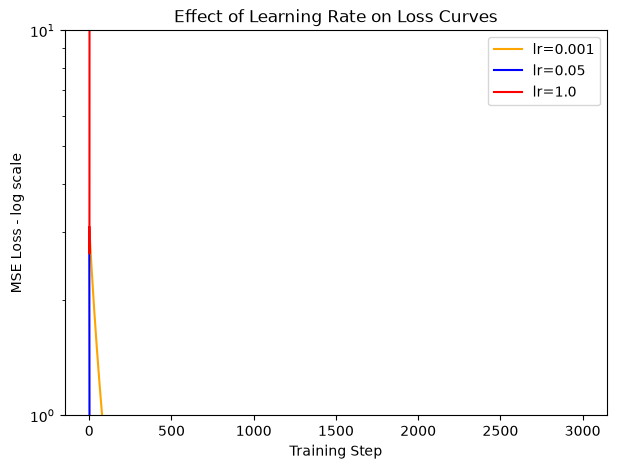

In [9]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)
    loss_history = []

    #forward pass
    for step in range(steps):
        hidden_preactivation = x_input @ W1 + b1
        hidden_output = np.tanh(hidden_preactivation)
        y_hat = hidden_output @ W2 + b2
        loss = np.mean((y_hat - y_target) ** 2)
        loss_history.append(loss)

        #backward pass
        gradient_yhat = 2 * (y_hat - y_target) / len(y_target)
        gradient_W2 = hidden_output.T @ gradient_yhat
        gradient_b2 = gradient_yhat.sum(axis=0)
        gradient_hidden_output = gradient_yhat @ W2.T
        gradient_hidden_preactivation = gradient_hidden_output * (1 - np.tanh(hidden_preactivation) ** 2)
        gradient_W1 = x_input.T @ gradient_hidden_preactivation
        gradient_b1 = gradient_hidden_preactivation.sum(axis=0)

        #parameter update
        W1 -= lr * gradient_W1
        b1 -= lr * gradient_b1
        W2 -= lr * gradient_W2
        b2 -= lr * gradient_b2

    return loss_history

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learning_rates = [0.001, 0.05, 1.0]
loss_histories_curves = {}

for lr in learning_rates:
    loss_histories_curves[lr] = train_toy(lr, steps=3000)
    print(f"lr={lr}: final loss for learning rate = {loss_histories_curves[lr][-1]:.5f}")

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(7, 5))
colors = ['orange', 'blue', 'red']

for lr, color in zip(learning_rates, colors):
    plt.plot(loss_histories_curves[lr], label=f"lr={lr}", color=color)
plt.yscale('log')
plt.title("Effect of Learning Rate on Loss Curves")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss - log scale")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
lr = 0.001 shows loss barely decreases with too small steps, making training crawls.
lr = 0.05 shows loss decreases smoothly to a low value with a well-sized steps for the loss surface.
lr= 1.0 shows loss oscillates instead of decreasing making steps too large.

**Why "too hot" explodes instead of just learning faster**
Gradient says nothing about how far the slope holds but instead only points toward the steepest direction at the current point.With too large a step, you overshoot the minimum and land somewhere even steeper on the other side. Each following update overshoots by more than the last, so instead of settling down, the loss oscillates or blows up. 


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [18]:
OBESITY_URL="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

obesity_data = pd.read_csv(OBESITY_URL)  # Replace with actual URL
obesity_clean = obesity_data.copy()

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_columns = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_columns:
     obesity_clean[col] = (obesity_clean[col].str.lower() == "yes").astype(int)
caec_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity_clean['CAEC'] = obesity_clean['CAEC'].map(caec_order)
obesity_clean['CALC'] = obesity_clean['CALC'].map(calc_order)

obesity_clean = pd.get_dummies(obesity_clean, columns=['Gender', 'MTRANS'], drop_first=True)

#Encoding the target variable "NObeyesdad" into integers 0..6
label_encoder = LabelEncoder()
obesity_clean['target'] = label_encoder.fit_transform(obesity_clean['NObeyesdad'])  # Assuming the target column is named 'NObeyesdad'
features = [col for col in obesity_clean.columns if col not in ['NObeyesdad', 'target']]
X_obesity = obesity_clean[features]
Y_obesity = obesity_clean['target']



# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(X_obesity, Y_obesity, test_size=0.40, stratify=Y_obesity, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train set: {X_train.shape[0]} samples, Validation set: {X_val.shape[0]} samples, Test set: {X_test.shape[0]} samples")

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Creating DataLoaders for training, validation, and test sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader batches: {len(train_loader)}, Validation loader batches: {len(val_loader)}, Test loader batches: {len(test_loader)}")

print(f"Data loaders initialized.")
print(f"Input feature dimension: {X_train_tensor.shape[1]}")

Train set: 1266 samples, Validation set: 422 samples, Test set: 423 samples
Train loader batches: 40, Validation loader batches: 14, Test loader batches: 14
Data loaders initialized.
Input feature dimension: 19


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
1. PyTorch CrossEntropyLoss applies log_softmax internally, then looks up the log-probability at the index given by the integer label. Integer labels make this a direct lookup, therefore there is no need to build a one-hot vector and multiply it through.
2. Random forests split on one feature's threshold at a time, so scale never affects which splits get chosen. Neural networks, by contrast, train through gradient descent, and Section 1 showed the gradient for a weight scales with its input value (dw = mean(2*(y_hat-y)*x)). Scaling puts every feature's gradient contribution on comparable footing.
3. "shuffle = True" reshuffles the training examples into new batches every epoch. This stops the model from picking up on any accidental ordering in the data (like rows being sorted by class), which helps gradient descent generalize instead of overfitting to a fixed batch sequence.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [22]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[1], n_classes)
       

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        logits = self.output_layer(x)  # Output layer (logits)
        return logits

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_tensor.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

#verify the count for the first layer
first_layer_params = input_dim * 64 + 64
print(f"First layer (by hand): {input_dim} * 64 + 64 = {first_layer_params}")
print(f"First layer (PyTorch): {sum(p.numel() for p in model.layer1.parameters())}")

FeedForwardNet(
  (layer1): Linear(in_features=19, out_features=64, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
)
Total trainable parameters: 3591
First layer (by hand): 19 * 64 + 64 = 1280
First layer (PyTorch): 1280


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 
1. Layer 1 (input = 64): 19×64 + 64 = 1280
Layer 2 (64 = 32): 64×32 + 32 = 2080
Output layer (32→7): 32×7 + 7 = 231
Total: 1280 + 2080 + 231 = 3591
This matches the "sum(p.numel()for p in model.parameters()).

2. ReLU is faster to compute than tanh, since it's just max(0, x) with no exponentials involved. It also avoids the vanishing gradient problem for positive inputs: tanh's derivative shrinks toward 0 for large |x|, which can slow learning in deeper networks, while ReLU's gradient stays at exactly 1 for any positive input.

3. Without ReLUs, this stack of Linear layers would collapse into a single linear transformation, like what I proved mathematically in Part 1.2's Student Reasoning. The network would only be able to represent linear decision boundaries between the 7 classes, no matter how many layers you stack.


### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch [ 1/50] - Train Loss: 1.8554, Train Acc: 0.3191 - Val Loss: 1.7249, Val Acc: 0.4100
Epoch [ 2/50] - Train Loss: 1.5629, Train Acc: 0.4629 - Val Loss: 1.4001, Val Acc: 0.5024
Epoch [ 3/50] - Train Loss: 1.2334, Train Acc: 0.5735 - Val Loss: 1.1287, Val Acc: 0.6043
Epoch [ 4/50] - Train Loss: 0.9807, Train Acc: 0.6493 - Val Loss: 0.9608, Val Acc: 0.6611
Epoch [ 5/50] - Train Loss: 0.8178, Train Acc: 0.7141 - Val Loss: 0.8539, Val Acc: 0.7133
Epoch [ 6/50] - Train Loss: 0.7023, Train Acc: 0.7757 - Val Loss: 0.7948, Val Acc: 0.7464
Epoch [ 7/50] - Train Loss: 0.6097, Train Acc: 0.7994 - Val Loss: 0.7131, Val Acc: 0.7915
Epoch [ 8/50] - Train Loss: 0.5316, Train Acc: 0.8239 - Val Loss: 0.6624, Val Acc: 0.8081
Epoch [ 9/50] - Train Loss: 0.4639, Train Acc: 0.8570 - Val Loss: 0.6209, Val Acc: 0.8389
Epoch [10/50] - Train Loss: 0.4099, Train Acc: 0.8744 - Val Loss: 0.5846, Val Acc: 0.8389
Epoch [11/50] - Train Loss: 0.3608, Train Acc: 0.8886 - Val Loss: 0.5766, Val Acc: 0.8507
Epoch [12/

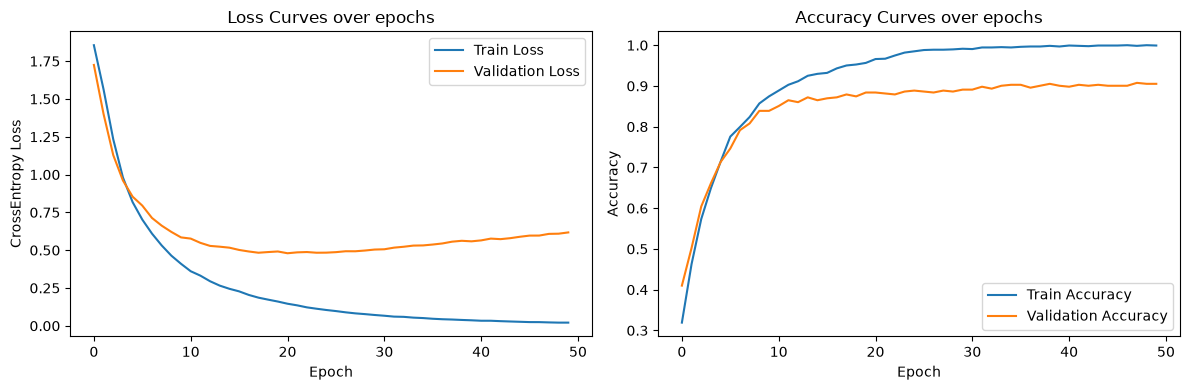

In [24]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
n_epochs = 50
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}
best_val_acc = 0.0  # To track the best validation accuracy

for epoch in range(n_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        predicted = logits.argmax(dim=1)
        total_train += yb.size(0)
        correct_train += (predicted == yb).sum().item()

    running_loss /= total_train
    train_acc = correct_train / total_train

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)
            predicted = logits.argmax(dim=1)
            total_val += yb.size(0)
            correct_val += (predicted == yb).sum().item()

    val_running_loss /= total_val
    val_acc = correct_val / total_val

    # Append to history
    history['train_loss'].append(running_loss)
    history['val_loss'].append(val_running_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Print summary for the epoch
    print(f"Epoch [{epoch+1:2d}/{n_epochs}] - "
          f"Train Loss: {running_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_running_loss:.4f}, Val Acc: {val_acc:.4f}")

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), "ffn_best.pt")
    print(f"Best model saved with validation accuracy: {best_val_acc:.4f}")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Validation Loss')
axes[0].set_title("Loss Curves over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Validation Accuracy')
axes[1].set_title("Accuracy Curves over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 
1. Mapping the PyTorch loop to your Section 1 NumPy code:

PyTorch line  →	Section 1 equivalent
logits = model(xb)  →	forward pass: z1 = x@W1+b1; h=tanh(z1); y_hat = h@W2+b2
loss = criterion(logits, yb)  →	loss = np.mean((y_hat - y)**2)
loss.backward()   →	      backward pass(manually): computing dW2, db2, dh, dz1, dW1, db1
optimizer.step()  →	 manual update: W1 -= lr*dW1, etc.
optimizer.zero_grad()  →	(no NumPy equivalent needed — gradients were freshly computed each loop, not accumulated)

2. The model is overfitting. Frpm my result, Val loss bottoms out around epoch 18 to 21 at roughly 0.48, then climbs steadily to 0.6175 by epoch 50, even as train loss keeps falling to 0.021 and train accuracy reaches 100% by epoch 49. Val accuracy plateaus around 88 to 90% and barely moves after epoch 20. Train loss dropping to near zero while val loss rises is the clearest sign the model is memorizing the training set instead of generalizing.

3. PyTorch accumulates gradients on each .backward() call rather than overwriting them. Without zero_grad(), each batch's gradients would stack on top of the last, so the update at batch 2 would reflect batch 1 and batch 2 combined, batch 3 would reflect all three, and so on. This corrupts the training signal and effectively inflates the learning rate as training continues.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Running experiment with capacity: tiny (8,)
Running experiment with capacity: default (64, 32)
Running experiment with capacity: large (256, 128, 64)


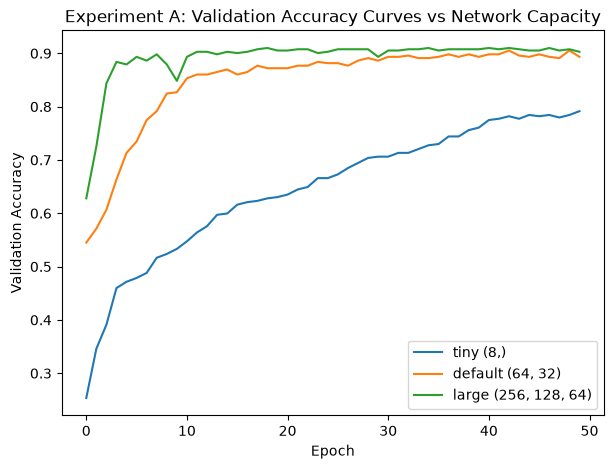

Running experiment with learning rate: 0.0001
Running experiment with learning rate: 0.001
Running experiment with learning rate: 0.1


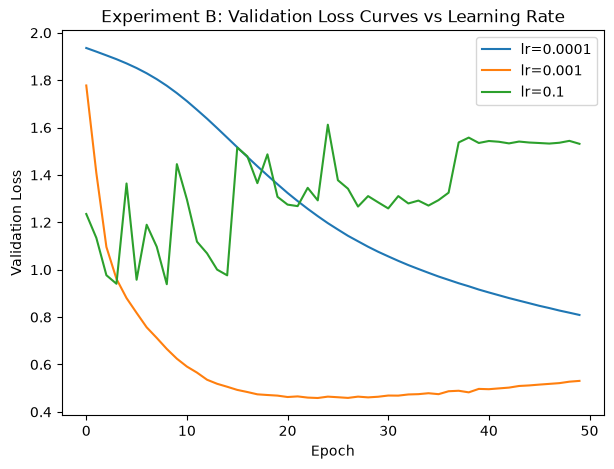

Running experiment with dropout: 0.0
Running experiment with dropout: 0.3


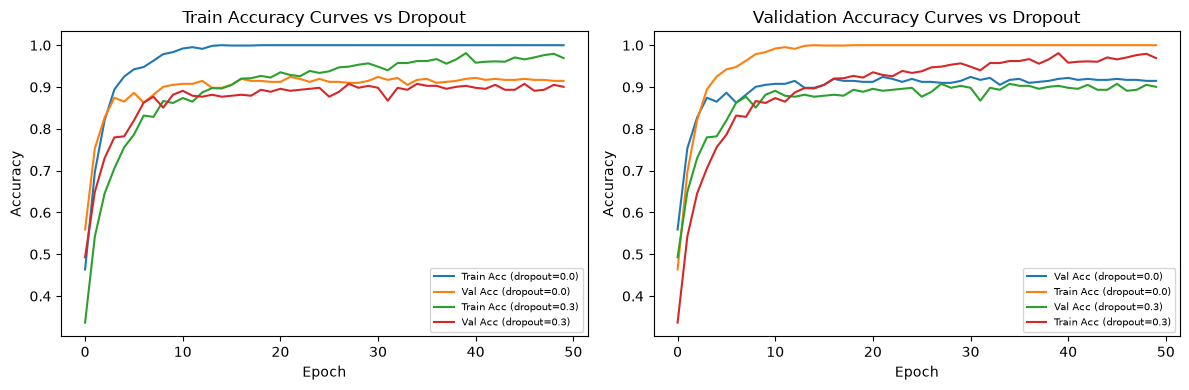

In [29]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    #including dropout if specified
    class FFN(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes, dropout):
            super().__init__()
            layers = []
            prev_dim = input_dim
            for h in hidden_sizes:
                layers.append(nn.Linear(prev_dim, h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_dim = h
            layers.append(nn.Linear(prev_dim, n_classes))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    model_exp = FFN(input_dim=X_train_tensor.shape[1], hidden_sizes=hidden_sizes,
                     n_classes=7, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_exp.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # training
        model_exp.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model_exp(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        # validation
        model_exp.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model_exp(xb)
                loss = criterion(logits, yb)
                val_running_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += yb.size(0)
        history["val_loss"].append(val_running_loss / val_total)
        history["val_acc"].append(val_correct / val_total)

    return history
    

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
capacity_configs = {
    "tiny (8,)": (8,),
    "default (64, 32)": (64, 32),
    "large (256, 128, 64)": (256, 128, 64)
}
capacity_history_results = {}
for name, hidden_sizes in capacity_configs.items():
    print(f"Running experiment with capacity: {name}")
    history = run_experiment(hidden_sizes=hidden_sizes, lr=1e-3, batch_size=32, epochs=50, dropout=0.0)
    capacity_history_results[name] = history

plt.figure(figsize=(7, 5))
for name, history in capacity_history_results.items():
    plt.plot(history['val_acc'], label=name)
plt.title("Experiment A: Validation Accuracy Curves vs Network Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()    

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
lr_configs = [1e-4, 1e-3, 1e-1]
lr_history_results = {}
for lr in lr_configs:
    print(f"Running experiment with learning rate: {lr}")
    history = run_experiment(hidden_sizes=(64, 32), lr=lr, batch_size=32, epochs=50, dropout=0.0)
    lr_history_results[lr] = history

plt.figure(figsize=(7, 5))
for lr, history in lr_history_results.items():
    plt.plot(history['val_loss'], label=f"lr={lr}")
plt.title("Experiment B: Validation Loss Curves vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()    

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
dropout_configs = [0.0, 0.3]
dropout_history_results = {}
for dropout in dropout_configs:
    print(f"Running experiment with dropout: {dropout}")
    history = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, batch_size=32, epochs=50, dropout=dropout)
    dropout_history_results[dropout] = history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dropout, history in dropout_history_results.items():
    axes[0].plot(history['train_acc'], label=f"Train Acc (dropout={dropout})")
    axes[0].plot(history['val_acc'], label=f"Val Acc (dropout={dropout})")
    axes[1].plot(history['val_acc'], label=f"Val Acc (dropout={dropout})") 
    axes[1].plot(history['train_acc'], label=f"Train Acc (dropout={dropout})")
axes[0].set_title("Train Accuracy Curves vs Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize='7')

axes[1].set_title("Validation Accuracy Curves vs Dropout")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize='7')

plt.tight_layout()
plt.show()

In [31]:
print("=== Capacity ===")
for name, hist in capacity_history_results.items():
    print(f"{name}: final val_acc={hist['val_acc'][-1]:.4f}, best val_acc={max(hist['val_acc']):.4f}")

print("\n=== Learning rate ===")
for lr_configs, hist in lr_history_results.items():
    print(f"lr={lr_configs}: final val_loss={hist['val_loss'][-1]:.4f}, min val_loss={min(hist['val_loss']):.4f}")

print("\n=== Dropout ===")
for dropout, hist in dropout_history_results.items():
    gap = hist['train_acc'][-1] - hist['val_acc'][-1]
    print(f"dropout={dropout}: final train_acc={hist['train_acc'][-1]:.4f}, "
          f"final val_acc={hist['val_acc'][-1]:.4f}, train-val gap={gap:.4f}")

=== Capacity ===
tiny (8,): final val_acc=0.7915, best val_acc=0.7915
default (64, 32): final val_acc=0.8934, best val_acc=0.9052
large (256, 128, 64): final val_acc=0.9028, best val_acc=0.9100

=== Learning rate ===
lr=0.0001: final val_loss=0.8090, min val_loss=0.8090
lr=0.001: final val_loss=0.5307, min val_loss=0.4585
lr=0.1: final val_loss=1.5314, min val_loss=0.9387

=== Dropout ===
dropout=0.0: final train_acc=1.0000, final val_acc=0.9147, train-val gap=0.0853
dropout=0.3: final train_acc=0.9692, final val_acc=0.9005, train-val gap=0.0687


**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** 
1. The large network won on validation accuracy (0.9100 best), but only marginally ahead of default (0.9052). Tiny clearly underperformed at 0.7915, showing it lacks the capacity to capture the pattern. The gap between default and large is small, only about half a percent, showing diminishing returns once you're past a moderate size. There is no clear overfitting signal in these best-accuracy numbers alone, but the small improvement for a 4x parameter increase confirms more capacity stops paying off quickly on a dataset this size.

2. Yes, the same three regimes from Part 1.3 show up here. lr=0.0001 is too cold: val loss stays stuck high at 0.8090 with barely any progress. lr=0.001 hits the sweet spot, reaching the lowest val loss at 0.4585. lr=0.1 is too hot: val loss ends up at 1.5314, well above its lowest point of 0.9387, showing instability instead of steady convergence. Same pattern, different dataset.

3. Dropout narrowed the train-val gap from 0.0853 down to 0.0687. Without it, the model hits 100% train accuracy while validation sits around 91%, a clear memorization signal. With dropout, train accuracy drops to 96.92%, but the smaller gap to validation shows better generalization. Dropout works by randomly turning off a fraction of neurons on each training step, which stops the network from leaning too heavily on any one neuron or fixed pathway, pushing it toward a more robust representation instead of memorizing the training data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9338, Test Macro-F1: 0.9312

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        54
      Normal_Weight       0.84      0.79      0.81        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.86      0.84      0.85        58
Overweight_Level_II       0.91      1.00      0.95        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



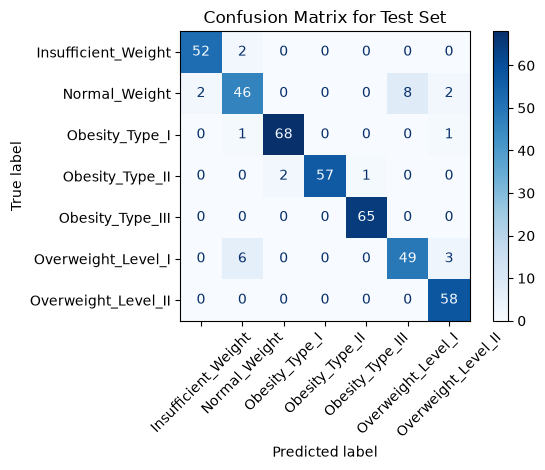

,Model,Test Accuracy,Test Macro-F1,Parameters / Trees
0,Random Forest (Lab 2),0.992900,0.992600,"100 trees, max_depth=15"
1,Neural Network (Lab 3),0.933806,0.931181,3591 params


In [42]:
# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        predictions = logits.argmax(dim=1).cpu().numpy()
        all_predictions.extend(predictions)
        all_true_labels.extend(yb.numpy())

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report

test_accuracy = accuracy_score(all_true_labels, all_predictions)
test_macro_f1 = f1_score(all_true_labels, all_predictions, average='macro')
print(f"Test Accuracy: {test_accuracy:.4f}, Test Macro-F1: {test_macro_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=label_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(all_true_labels, all_predictions, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Test Set")
plt.tight_layout()
plt.show()




# TODO: Build a small comparison table (a pandas DataFrame is fine):

#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison = pd.DataFrame({
    "Model": ["Random Forest (Lab 2)", "Neural Network (Lab 3)"],
    "Test Accuracy": [0.9929, test_accuracy],
    "Test Macro-F1": [0.9926, test_macro_f1],
    "Parameters / Trees": ["100 trees, max_depth=15", f"{sum(p.numel() for p in model.parameters())} params"],
})

comparison

In [41]:
#Adding the training time column
import time
start_time = time.time()
#training loop
training_time = time.time() - start_time

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** 
1. The network has the most trouble with Normal_Weight (81% f1) and Overweight_Level_I (85% f1), the two lowest scoring classes, with Insufficient_Weight sitting right next to that same boundary too. These are neighboring weight categories with overlapping feature values, so the model mixes them up most. Lab 2's Random Forest confused the exact same pair, Insufficient_Weight and Normal_Weight, but only made 1 mistake there. So both models stumble in the same spot, just the neural network stumbles a lot more.

2. The Random Forest wins by a clear margin, 99.29% accuracy against 93.38% for the neural network, and 0.9926 versus 0.9312 macro-F1. On this dataset, building and tuning a neural network was not worth the extra effort. With only 2,111 rows of tabular data, this is exactly the kind of setting where tree based models tend to beat neural networks, since trees can find good splits without needing much data. Deep learning would pay off on larger datasets, or with data types like images, text, or audio, where a network can pick up on patterns that simple splits cannot capture.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 

1. `loss.backward()` looks at how much each weight and bias contributed to the error, using the chain rule, the same thing I did by hand in Section 1. `optimizer.step()` then updates every weight and bias to make the loss a bit smaller next time. Behind the scenes, PyTorch remembers every step of the forward pass so it can trace the error back through each layer.

2. I would pick the learning rate. It made the biggest difference in both Part 1.3 and Part 2.4, if it was too low the model barely learned anything, and if it was too high the loss became unstable or blew up. Other settings like hidden size or dropout only improved things a little, but the learning rate decided whether training worked at all.

3. I saw the biggest gap between train and validation in Part 2.3, where my train accuracy hit 100% but validation stayed around 90%. Adding dropout in Part 2.4 closed that gap the most, from 0.0853 down to 0.0687, by stopping the network from depending too much on any single neuron.

4. A plain MLP treats every pixel as its own separate input with its own weight, so it has no idea which pixels sit next to each other or form a shape. This means it would not recognize the same object if it moved to a different spot in the image. A better architecture needs to understand spatial locality, looking at small groups of nearby pixels together and reusing the same filters across the whole image.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.